In [3]:
from dataset_augmented_simulation import AugmentedSimulationDataset
import numpy as np
import matplotlib.pyplot as plt
def test_augmented_dataset_visualization(data_length, scenarios, data_folder, num_samples=5):
    """
    Visualize random samples from AugmentedSimulationDataset.
    Plots the scenario map and overlays the observed track.
    """
    dataset = AugmentedSimulationDataset(
        data_length=data_length,
        scenarios=scenarios,
        data_folder=data_folder,
        load_scenario_map=True
    )
    for i in range(num_samples):
        idx = np.random.randint(len(dataset))
        sample = dataset[idx]
        scen_map = sample['scen_map']
        track = sample['observed_data']
        mask = sample['observed_mask']

        plt.figure(figsize=(5, 5))
        plt.imshow(scen_map.astype(np.uint8))
        # mask is (T, 2) for (x, y); valid if both True
        valid_points = track[(mask[:, 0] & mask[:, 1])]
        if valid_points.shape[0] > 0:
            plt.plot(valid_points[:, 0], valid_points[:, 1], marker='o', color='red')
        plt.title(f'Sample {i}')
        plt.axis('off')
        plt.show()

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from dataset_simulation import Simulation_Dataset

def visualize_simulation_dataset(data_length, scenarios, data_folder, mode="train", num_samples=5):
    """
    Visualize tracks on scenario map, restoring zero-based offset and flipping Y for correct alignment.
    """
    dataset = Simulation_Dataset(
        data_length=data_length,
        scenarios=scenarios,
        data_folder=data_folder,
        mode=mode,
        load_scenario_map=True,
        zero_based_position=True
    )

    for i in range(num_samples):
        index = np.random.randint(len(dataset))
        sample = dataset[index]
        scenario_index, scenario_name = dataset.get_index(index)

        scen_map = sample['scen_map']
        track = sample['observed_data']
        mask = sample['observed_mask']
        scale = sample.get('scen_map_scale', np.array([1.0, 1.0]))

        # Restore original origin (undo zero-based offset)
        origin_offset = dataset.origin_position[scenario_name]
        #print(f"Visualizing scenario {scenario_name} at index {index} with origin offset {origin_offset}")
        #track = track + origin_offset  # shape (T, 2)

        # Scale
        track_scaled = track * scale

        # Flip Y
        map_height = scen_map.shape[0]
        track_scaled[:, 1] = map_height - track_scaled[:, 1]

        # Plot
        plt.figure(figsize=(5, 5))
        plt.imshow(scen_map.astype(np.uint8))
        valid_points = track_scaled[(mask[:, 0] & mask[:, 1])]
        if valid_points.shape[0] > 0:
            plt.plot(valid_points[:, 0], valid_points[:, 1], marker='o', color='red', linewidth=1, markersize=4)
        plt.title(f"Scenario {scenario_name} | Sample {i}")
        plt.axis('off')
        plt.show()

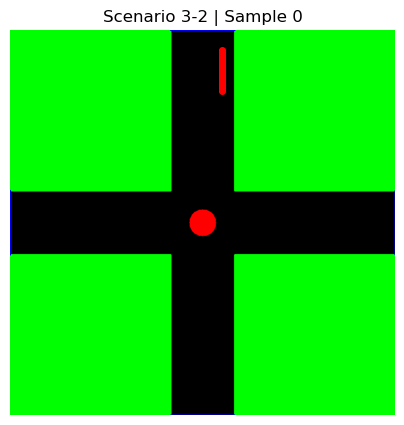

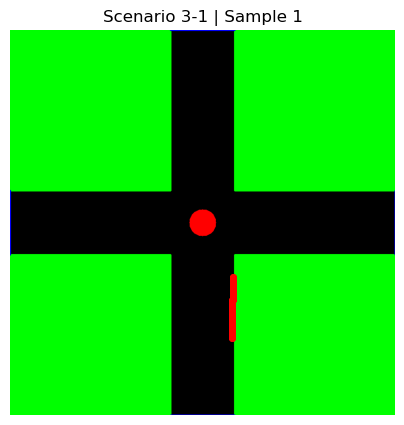

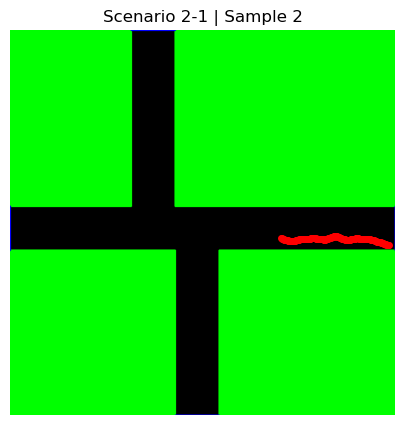

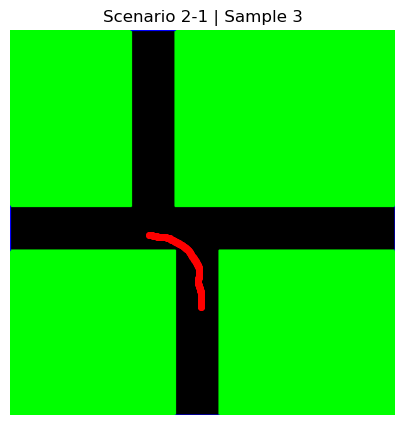

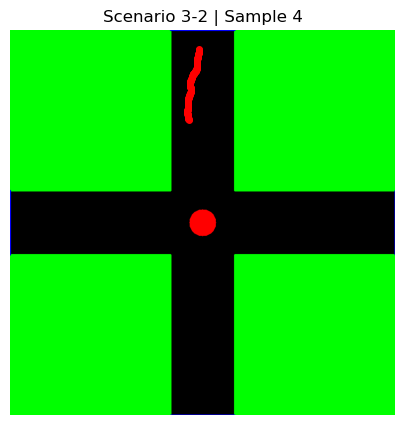

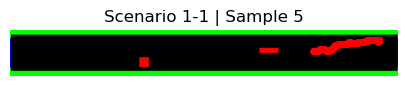

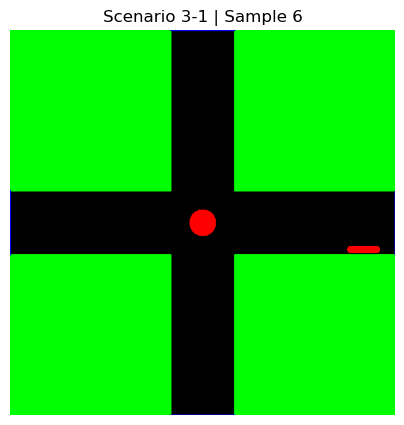

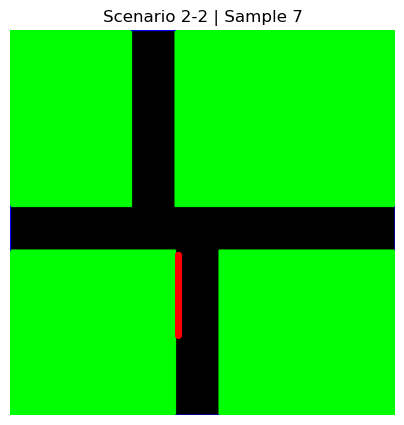

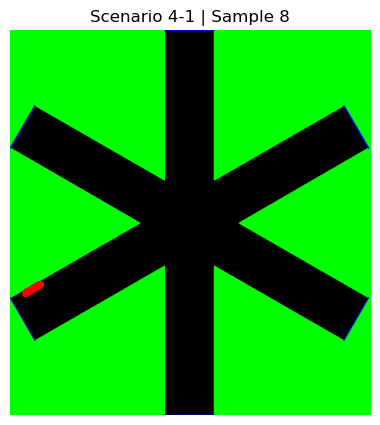

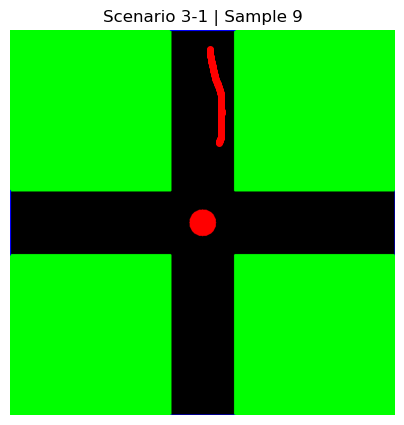

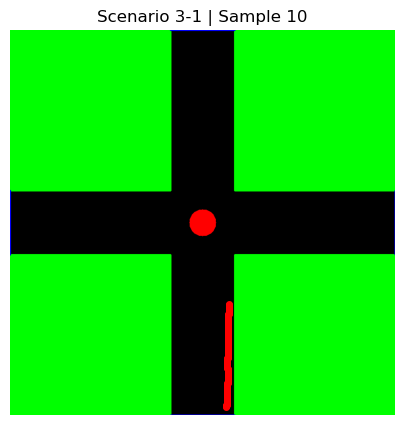

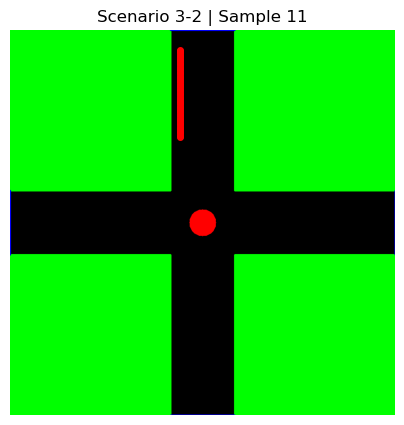

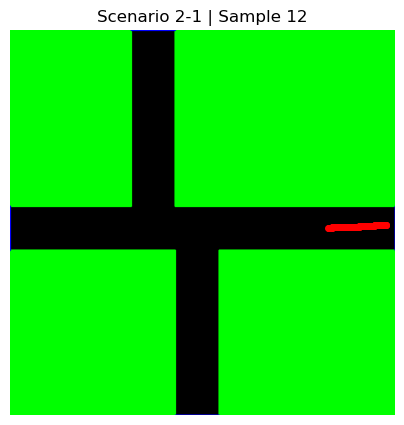

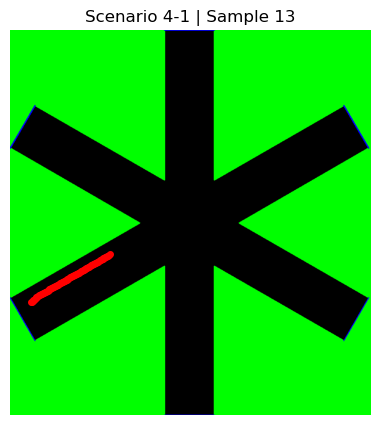

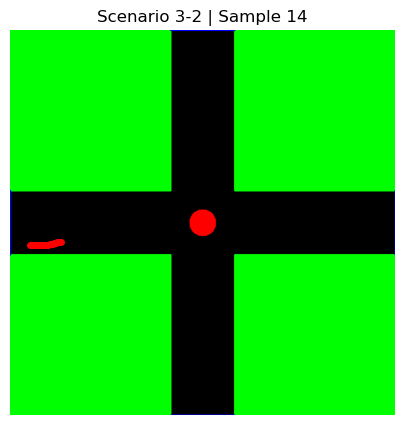

In [5]:
data_length = 200
scenairos = None
data_folder = None
visualize_simulation_dataset(data_length, scenairos, data_folder, mode="train", num_samples=15)
#test_augmented_dataset_visualization(data_length, scenairos, data_folder)

In [387]:
# Debug the dataset and visualize the tracks step by step
data_length = 200
scenarios = None
data_folder = None
resize_to = (256, 128)  # Resize to 128x128 for visualization
dataset = AugmentedSimulationDataset(
        data_length=data_length,
        scenarios=scenarios,
        data_folder=data_folder,
        load_scenario_map=True,
        resize_to=resize_to,
        debug=True  # Enable debug mode to visualize tracks on scenario map
    )

In [388]:
import cv2
index = 6280
index, scenario = dataset.get_index(index)
track = dataset.data[scenario][index]

observed_values, observed_masks, gt_masks, time_points, person_ids = dataset._parse_single_data(
    track, scenario, missing_ratio=dataset.missing_ratio, missing_strategy=dataset.missing_strategy)
scen_map_raw = dataset.scen_map[scenario]
desired_crop_size = dataset.resize_to

scen_map_raw = scen_map_raw.copy()
map_height = scen_map_raw.shape[0]
for t in range(len(observed_values)):
    x, y = observed_values[t]
    y = y * dataset.scen_map_base_scale  # Scale y-coordinate by the base scale
    x = x * dataset.scen_map_base_scale  # Scale x-coordinate by the base
    # Flip y-coordinate to match image coordinates
    y = map_height - y

    if 0 <= x < scen_map_raw.shape[1] and 0 <= y < scen_map_raw.shape[0]:
        cv2.circle(scen_map_raw, (int(x), int(y)), 3, (0, 0, 255), -1)

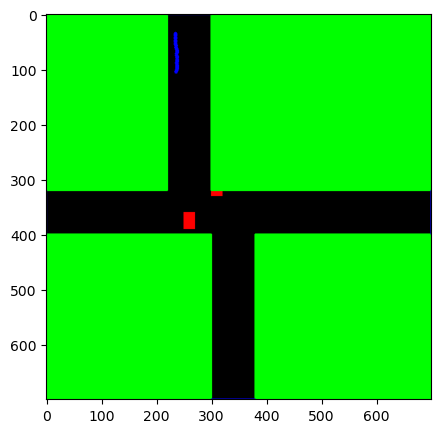

In [389]:
plt.figure(figsize=(5, 5))
plt.imshow(scen_map_raw.astype(np.uint8))

In [390]:
H, W, _ = scen_map_raw.shape

# Bounding box around the track
masked_value = np.where(observed_masks, observed_values, np.nan)
masked_value = masked_value * dataset.scen_map_base_scale  # Scale by the base scale
masked_value[:, 1] = H - masked_value[:, 1]  # Flip y-coordinate to match image coordinates

# Bounding box around the track
min_x, min_y = np.nanmin(masked_value, axis=0) 
max_x, max_y = np.nanmax(masked_value, axis=0) 
min_x = np.floor(min_x)
max_x = np.ceil(max_x)
min_y = np.floor(min_y)
max_y = np.ceil(max_y)
print(f"H: {H}, W: {W}, min_x: {min_x}, max_x: {max_x}, min_y: {min_y}, max_y: {max_y}")
#min_y, max_y = H - max_y, H-min_y  # Flip y-coordinate to match image coordinates
#max_y = H - min_y  # Flip y-coordinate to match image coordinates
print(f"H: {H}, W: {W}, min_x: {min_x}, max_x: {max_x}, min_y: {min_y}, max_y: {max_y}")
bbox_w = max_x - min_x
bbox_h = max_y - min_y

# If the bounding box is too small, expand it to a minimum size
min_size = 30  # Minimum size for the bounding box
if bbox_w < min_size:
    print(f"Original min_x: {min_x}, max_x: {max_x}, bbox_w: {bbox_w}")
    min_x -= max(0, (min_size - bbox_w) / 2)
    max_x += min(W, (min_size - bbox_w) / 2)
    bbox_w = max_x - min_x
    print(f"Adjusted bbox width: {bbox_w} (min_x: {min_x}, max_x: {max_x})")
if bbox_h < min_size:
    print(f"Original min_y: {min_y}, max_y: {max_y}, bbox_h: {bbox_h}")
    min_y -= max(0, (min_size - bbox_h) / 2)
    max_y += min(H, (min_size - bbox_h) / 2)
    bbox_h = max_y - min_y
    print(f"Adjusted bbox height: {bbox_h} (min_y: {min_y}, max_y: {max_y})")

H: 700, W: 700, min_x: 235.0, max_x: 239.0, min_y: 35.0, max_y: 106.0
H: 700, W: 700, min_x: 235.0, max_x: 239.0, min_y: 35.0, max_y: 106.0
Original min_x: 235.0, max_x: 239.0, bbox_w: 4.0
Adjusted bbox width: 30.0 (min_x: 222.0, max_x: 252.0)


In [391]:
cropped_map_no_extend = scen_map_raw[int(min_y):int(max_y), int(min_x):int(max_x)].copy()

In [392]:
import random
# Apply asymmetric random margins
margin_left = random.randint(0, min(int(2 * bbox_w), int(min_x)))
margin_right = random.randint(0, min(int(2 * bbox_w), int(W - max_x)))
margin_top = random.randint(0, min(int(2 * bbox_h), int(min_y)))
margin_bottom = random.randint(0, min(int(2 * bbox_h), int(H - max_y)))

# calculate the margin_right and margin_bottom to achieve the desired aspect ratio
target_aspect = desired_crop_size[1] / desired_crop_size[0]
current_aspect = (max_x - min_x + margin_left) / (max_y - min_y + margin_top)
if current_aspect > target_aspect:
    print(f"current margin_bottom: {margin_bottom}, current margin_right: {margin_right}, target_aspect: {target_aspect}, current_aspect: {current_aspect}")
    # Too wide: adjust margin_bottom to match target aspect ratio
    margin_bottom = int((max_x - min_x + margin_left + margin_right) / target_aspect - (max_y - min_y + margin_top))
    margin_bottom = max(margin_bottom, 0)  # Ensure non-negative
    print(f"after margin_bottom: {margin_bottom}, margin_right: {margin_right}")
else:
    # Too tall: adjust margin_right to match target aspect ratio
    print(f"Tall current margin_bottom: {margin_bottom}, current margin_right: {margin_right}, target_aspect: {target_aspect}, current_aspect: {current_aspect}")
    margin_right = int((max_y - min_y + margin_top + margin_bottom) * target_aspect - (max_x - min_x + margin_left))
    margin_right = max(margin_right, 0) # Ensure non-negative
    new_current_aspect = (max_x - min_x + margin_left + margin_right) / (max_y - min_y + margin_top + margin_bottom)
    print(f"after margin_bottom: {margin_bottom}, margin_right: {margin_right}, target_aspect: {target_aspect}, old_aspect: {current_aspect},new_aspect: {new_current_aspect}")

# Proposed crop box
left = max(int(min_x) - margin_left, 0)
right = min(int(max_x) + margin_right, W)
top = max(int(min_y) - margin_top, 0)
bottom = min(int(max_y) + margin_bottom, H)

crop_w = right - left
crop_h = bottom - top
print(f"Crop box: left={left}, right={right}, top={top}, bottom={bottom}, crop_w={crop_w}, crop_h={crop_h}, margin_left={margin_left}, margin_right={margin_right}, margin_top={margin_top}, margin_bottom={margin_bottom}")

current margin_bottom: 40, current margin_right: 43, target_aspect: 0.5, current_aspect: 0.625
after margin_bottom: 110, margin_right: 43
Crop box: left=192, right=295, top=10, bottom=216, crop_w=103, crop_h=206, margin_left=30, margin_right=43, margin_top=25, margin_bottom=110


In [393]:
cropped_map_extend = scen_map_raw[top:bottom, left:right].copy()

In [394]:
# Compute padding needed to achieve target aspect ratio
current_aspect = crop_w / crop_h if crop_h != 0 else 1.0
target_aspect = desired_crop_size[1] / desired_crop_size[0]
print(f"Current aspect: {current_aspect}, Target aspect: {target_aspect}")

pad_top, pad_bottom, pad_left, pad_right = 0, 0, 0, 0
if current_aspect > target_aspect:
    # Too wide: pad height
    target_crop_h = int(crop_w / target_aspect)
    pad_total = max(target_crop_h - crop_h, 0)
    pad_top = pad_total // 2
    pad_bottom = pad_total - pad_top
elif current_aspect < target_aspect:
    # Too tall: pad width
    target_crop_w = int(crop_h * target_aspect)
    pad_total = max(target_crop_w - crop_w, 0)
    pad_left = pad_total // 2
    pad_right = pad_total - pad_left

# Crop and pad
cropped_map = scen_map_raw[top:bottom, left:right].copy()
print(f"Cropped map shape: {cropped_map.shape}, Padding: top={pad_top}, bottom={pad_bottom}, left={pad_left}, right={pad_right}")

Current aspect: 0.5, Target aspect: 0.5
Cropped map shape: (206, 103, 3), Padding: top=0, bottom=0, left=0, right=0


In [395]:
scaled_track = observed_values * dataset.scen_map_base_scale
fliped_track = scaled_track.copy()
map_height = scen_map_raw.shape[0]
fliped_track[:, 1] = map_height - fliped_track[:, 1]
cropped_track = fliped_track - np.array([left, top])
#cropped_track = scaled_track - np.array([left, bottom])

In [396]:
fliped_track[:5]

array([[236.465, 105.841],
       [236.93 , 104.832],
       [237.23 , 103.794],
       [237.398, 102.731],
       [237.67 , 101.682]])

In [397]:
cropped_track[:5]

array([[44.465, 95.841],
       [44.93 , 94.832],
       [45.23 , 93.794],
       [45.398, 92.731],
       [45.67 , 91.682]])

In [377]:
cropped_map_no_extend.shape

(71, 30, 3)

In [378]:
print(f"top: {top}, bottom: {bottom}, left: {left}, right: {right}")
scaled_track[:5]

top: 32, bottom: 221, left: 210, right: 399


array([[236.465, 594.159],
       [236.93 , 595.168],
       [237.23 , 596.206],
       [237.398, 597.269],
       [237.67 , 598.318]])

In [398]:
def draw_track_on_map(scen_map, track, mask):
    """
    Draw the track on the scenario map.
    """
    for t in range(len(track)):
        if mask[t, 0] == 1 and mask[t, 1] == 1:
            x, y = track[t]
            if 0 <= x < scen_map.shape[1] and 0 <= y < scen_map.shape[0]:
                cv2.circle(scen_map, (int(x), int(y)), 3, (255, 0, 128), -1)
            else:
                print(f"Warning: Track point {t} ({x}, {y}) is out of bounds for the scenario map.")

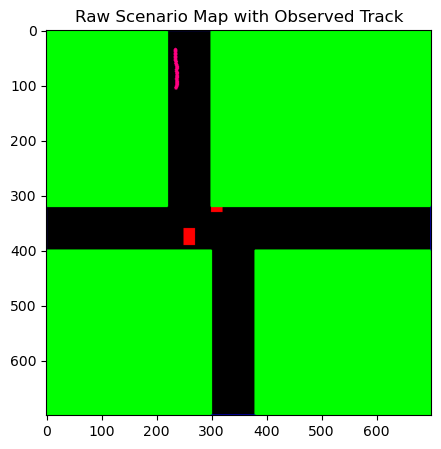

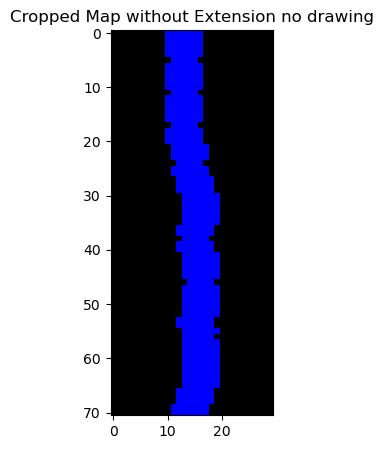

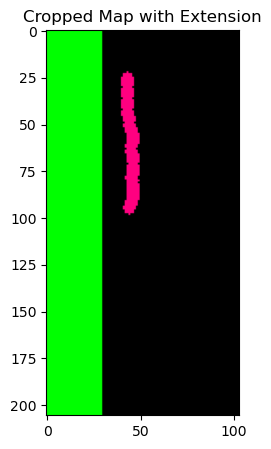

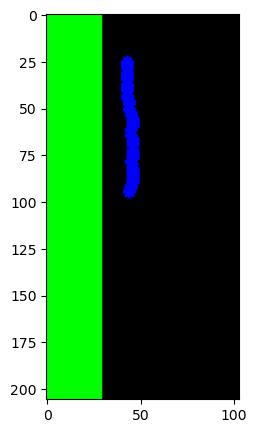

In [399]:
draw_track_on_map(scen_map_raw, fliped_track, observed_masks)
plt.figure(figsize=(5, 5))
# add title to the plot
plt.title("Raw Scenario Map with Observed Track")
plt.imshow(scen_map_raw.astype(np.uint8))

plt.figure(figsize=(5, 5))
plt.title("Cropped Map without Extension no drawing")
plt.imshow(cropped_map_no_extend.astype(np.uint8))

draw_track_on_map(cropped_map_extend, cropped_track, observed_masks)
plt.figure(figsize=(5, 5))
plt.title("Cropped Map with Extension")
plt.imshow(cropped_map_extend.astype(np.uint8))
plt.figure(figsize=(5, 5))
plt.imshow(cropped_map.astype(np.uint8))

In [147]:
if pad_top > 0 or pad_bottom > 0 or pad_left > 0 or pad_right > 0:
    padded_map = cv2.copyMakeBorder(
        cropped_map,
        pad_top, pad_bottom,
        pad_left, pad_right,
        borderType=cv2.BORDER_CONSTANT,
        value=0
    )
else:
    padded_map = cropped_map
print(f"Crop: ({left}, {top}) to ({right}, {bottom}), Padding: top={pad_top}, bottom={pad_bottom}, left={pad_left}, right={pad_right}")
print("padded map shape:", padded_map.shape)
if padded_map.shape[0] == 0 or padded_map.shape[1] == 0:
    print(f"Warning: Padded map has zero height or width. Crop: ({left}, {top}) to ({right}, {bottom}), Padding: top={pad_top}, bottom={pad_bottom}, left={pad_left}, right={pad_right}")
    print(f"track range: x=({observed_values[:, 0].min()}, {observed_values[:, 0].max()}), y=({observed_values[:, 1].min()}, {observed_values[:, 1].max()})")
print("padded aspect ratio:", padded_map.shape[1] / padded_map.shape[0], "target aspect ratio:", desired_crop_size[1] / desired_crop_size[0])

# Resize directly to target shape
final_map = cv2.resize(padded_map, desired_crop_size[::-1], interpolation=cv2.INTER_LINEAR)

Crop: (173, 0) to (527, 602), Padding: top=0, bottom=0, left=124, right=124
padded map shape: (602, 602, 3)
padded aspect ratio: 1.0 target aspect ratio: 1.0


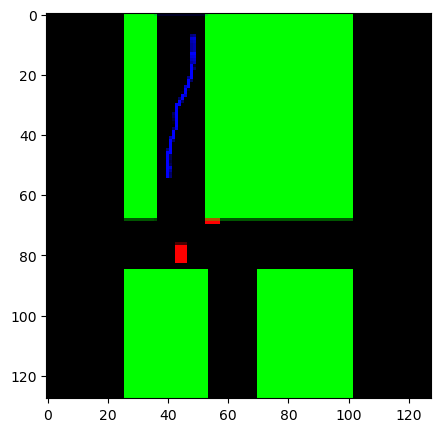

In [148]:
plt.figure(figsize=(5, 5))
plt.imshow(final_map.astype(np.uint8))

In [402]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from dataset_augmented_simulation import AugmentedSimulationDataset

def test_augmented_dataset_visualization(data_length, scenarios, data_folder, num_samples=5, resize_to=(128, 128)):
    """
    Visualize random samples from AugmentedSimulationDataset.
    """
    dataset = AugmentedSimulationDataset(
        data_length=data_length,
        scenarios=scenarios,
        data_folder=data_folder,
        load_scenario_map=True,
        resize_to=resize_to,
        debug=True  # Enable debug mode to visualize tracks on scenario map
    )

    for i in range(num_samples):
        idx = np.random.randint(len(dataset))
        sample = dataset[idx]
        scen_map = sample['scen_map']  # (H, W, 3)
        track = sample['observed_data'].copy()       # (T, 2)
        mask = sample['observed_mask']               # (T, 2)
        scale = sample['scen_map_scale']             # (2,)
        resize_shape = sample['resize_shape']        # (H, W)
        print(f"scale: {scale}, resize_shape: {resize_shape}")

        # Step 1: Convert track from map units to pixel space
        #track *= scale  # each track point is scaled by the X/Y pixel factor

        # Step 2: Flip Y to align with image coordinates
        #map_height = scen_map.shape[0]
        #track[:, 1] = map_height - track[:, 1]

        # Step 3: Filter only valid points
        valid_mask = (mask[:, 0] == 1) & (mask[:, 1] == 1)
        valid_points = track[valid_mask]

        # Step 4: Plot map + tracks
        plt.figure(figsize=(5, 5))
        plt.imshow(scen_map.astype(np.uint8))
        if valid_points.shape[0] > 0:
            plt.plot(valid_points[:, 0], valid_points[:, 1],
                     color='red', linewidth=1, marker='o', markersize=4)
        plt.title(f'Sample {i} (idx={idx})')
        plt.axis('off')
        plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Original min_x: 396.0, max_x: 397.0, bbox_w: 1.0
Adjusted bbox width: 30.0 (min_x: 381.5, max_x: 411.5)
Crop: (358, 21) to (463, 126), Padding: top=0, bottom=0, left=0, right=0
padded map shape: (105, 105, 3)
padded aspect ratio: 1.0 target aspect ratio: 1.0
Final map shape: (128, 128, 3), Crop size: (128, 128)
Scale: x=1.2190476190476192, y=1.2190476190476192
scale: [1.21904762 1.21904762], resize_shape: (128, 128)


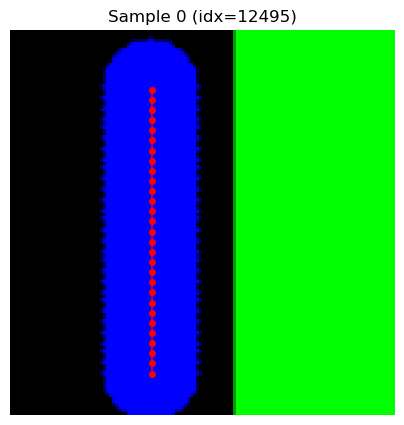

Original min_x: 414.0, max_x: 416.0, bbox_w: 2.0
Adjusted bbox width: 30.0 (min_x: 400.0, max_x: 430.0)
Crop: (378, 414) to (613, 649), Padding: top=0, bottom=0, left=0, right=0
padded map shape: (235, 235, 3)
padded aspect ratio: 1.0 target aspect ratio: 1.0
Final map shape: (128, 128, 3), Crop size: (128, 128)
Scale: x=0.5446808510638298, y=0.5446808510638298
scale: [0.54468085 0.54468085], resize_shape: (128, 128)


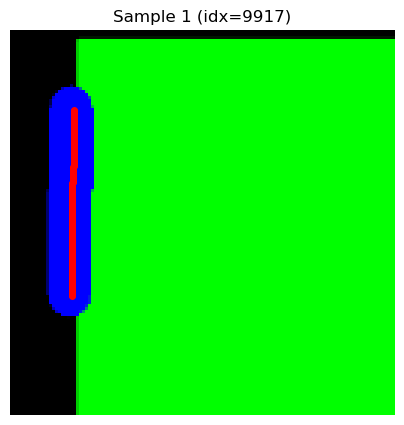

Original min_y: 374.0, max_y: 391.0, bbox_h: 17.0
Adjusted bbox height: 30.0 (min_y: 367.5, max_y: 397.5)
Crop: (481, 352) to (695, 566), Padding: top=0, bottom=0, left=0, right=0
padded map shape: (214, 214, 3)
padded aspect ratio: 1.0 target aspect ratio: 1.0
Final map shape: (128, 128, 3), Crop size: (128, 128)
Scale: x=0.5981308411214953, y=0.5981308411214953
scale: [0.59813084 0.59813084], resize_shape: (128, 128)


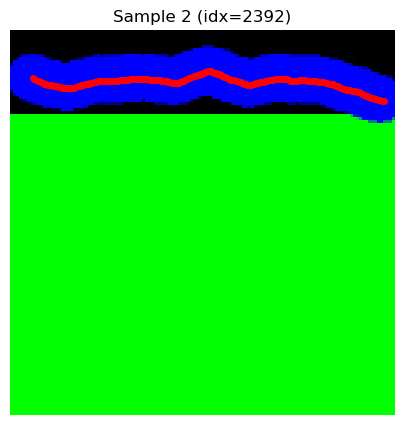

Crop: (162, 292) to (375, 505), Padding: top=0, bottom=0, left=0, right=0
padded map shape: (213, 213, 3)
padded aspect ratio: 1.0 target aspect ratio: 1.0
Final map shape: (128, 128, 3), Crop size: (128, 128)
Scale: x=0.6009389671361502, y=0.6009389671361502
scale: [0.60093897 0.60093897], resize_shape: (128, 128)


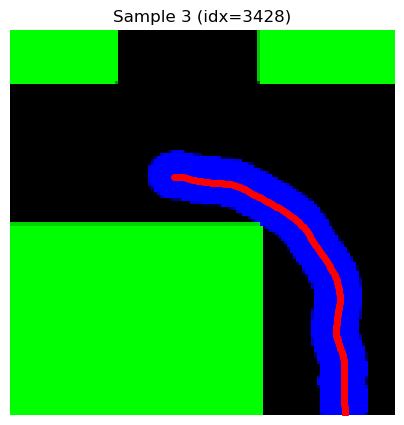

scale: [10 10], resize_shape: (128, 128)


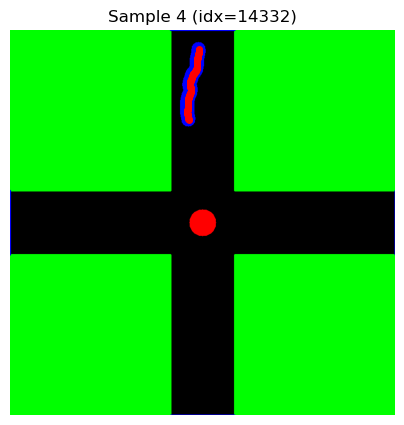

Original min_y: 21.0, max_y: 46.0, bbox_h: 25.0
Adjusted bbox height: 30.0 (min_y: 18.5, max_y: 48.5)
Crop: (563, 17) to (834, 100), Padding: top=94, bottom=94, left=0, right=0
padded map shape: (271, 271, 3)
padded aspect ratio: 1.0 target aspect ratio: 1.0
Final map shape: (128, 128, 3), Crop size: (128, 128)
Scale: x=0.47232472324723246, y=0.47232472324723246
scale: [0.47232472 0.47232472], resize_shape: (128, 128)


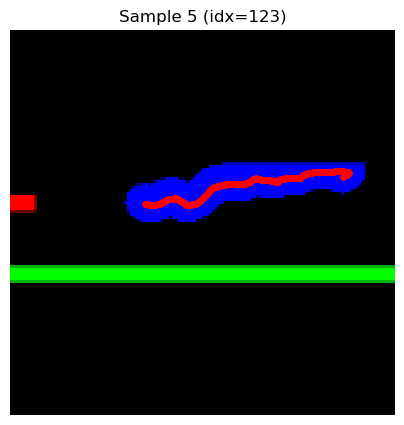

Original min_y: 409.0, max_y: 410.0, bbox_h: 1.0
Adjusted bbox height: 30.0 (min_y: 394.5, max_y: 424.5)
Crop: (606, 381) to (711, 486), Padding: top=0, bottom=0, left=0, right=0
padded map shape: (105, 105, 3)
padded aspect ratio: 1.0 target aspect ratio: 1.0
Final map shape: (128, 128, 3), Crop size: (128, 128)
Scale: x=1.2190476190476192, y=1.2190476190476192
scale: [1.21904762 1.21904762], resize_shape: (128, 128)


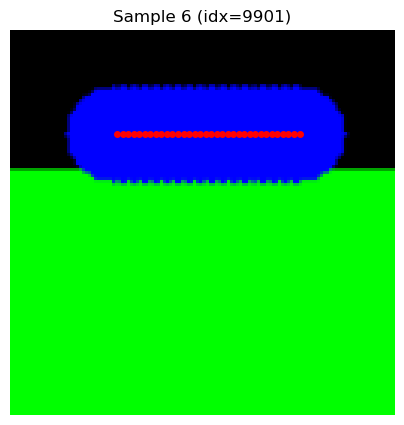

scale: [10 10], resize_shape: (128, 128)


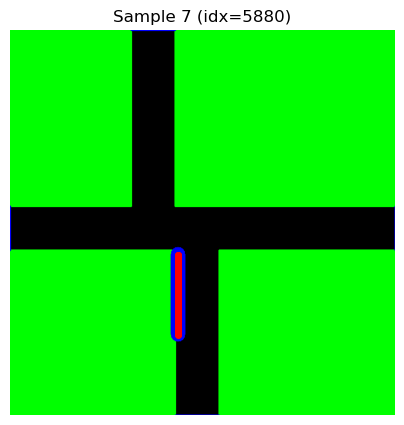

scale: [10 10], resize_shape: (128, 128)


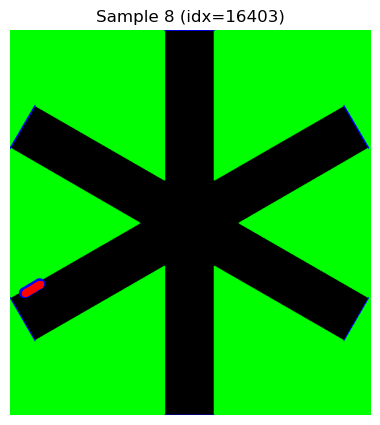

Original min_x: 373.0, max_x: 396.0, bbox_w: 23.0
Adjusted bbox width: 30.0 (min_x: 369.5, max_x: 399.5)
Crop: (341, 32) to (694, 385), Padding: top=0, bottom=0, left=0, right=0
padded map shape: (353, 353, 3)
padded aspect ratio: 1.0 target aspect ratio: 1.0
Final map shape: (128, 128, 3), Crop size: (128, 128)
Scale: x=0.3626062322946176, y=0.3626062322946176
scale: [0.36260623 0.36260623], resize_shape: (128, 128)


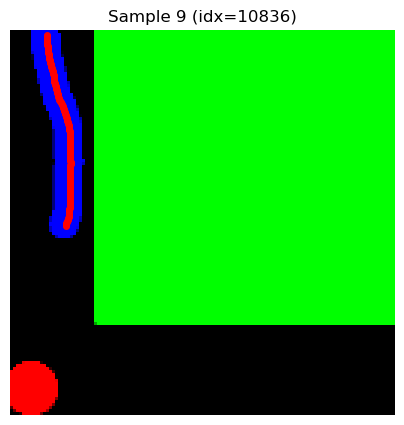

Original min_x: 404.0, max_x: 410.0, bbox_w: 6.0
Adjusted bbox width: 30.0 (min_x: 392.0, max_x: 422.0)
Crop: (388, 339) to (720, 715), Padding: top=0, bottom=0, left=22, right=22
padded map shape: (376, 376, 3)
padded aspect ratio: 1.0 target aspect ratio: 1.0
Final map shape: (128, 128, 3), Crop size: (128, 128)
Scale: x=0.3404255319148936, y=0.3404255319148936
scale: [0.34042553 0.34042553], resize_shape: (128, 128)


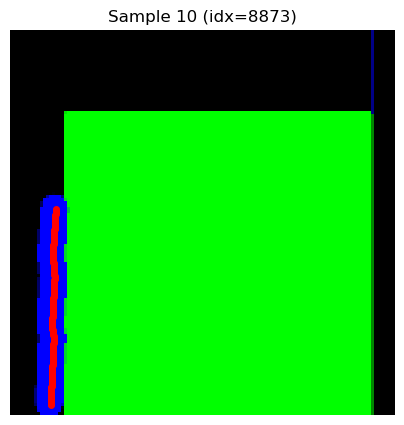

scale: [10 10], resize_shape: (128, 128)


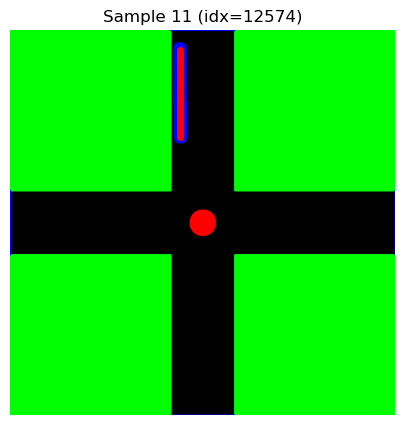

scale: [10 10], resize_shape: (128, 128)


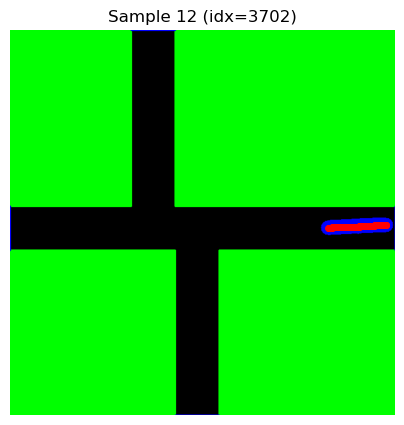

Crop: (28, 452) to (414, 838), Padding: top=0, bottom=0, left=0, right=0
padded map shape: (386, 386, 3)
padded aspect ratio: 1.0 target aspect ratio: 1.0
Final map shape: (128, 128, 3), Crop size: (128, 128)
Scale: x=0.3316062176165803, y=0.3316062176165803
scale: [0.33160622 0.33160622], resize_shape: (128, 128)


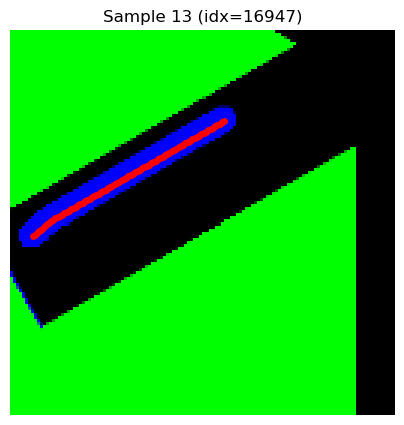

Original min_y: 395.0, max_y: 403.0, bbox_h: 8.0
Adjusted bbox height: 30.0 (min_y: 384.0, max_y: 414.0)
Crop: (36, 366) to (135, 465), Padding: top=0, bottom=0, left=0, right=0
padded map shape: (99, 99, 3)
padded aspect ratio: 1.0 target aspect ratio: 1.0
Final map shape: (128, 128, 3), Crop size: (128, 128)
Scale: x=1.292929292929293, y=1.292929292929293
scale: [1.29292929 1.29292929], resize_shape: (128, 128)


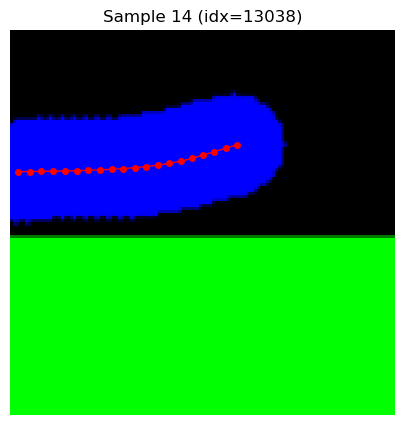

In [405]:
data_length = 200
scenairos = None
data_folder = None
test_augmented_dataset_visualization(data_length, scenairos, data_folder, num_samples=15)